<a href="https://colab.research.google.com/github/Mideva-S/fintrust_risk_prediction/blob/main/notebook/FinTrust_Week2_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#loading the customer_data file
from google.colab import files
uploaded = files.upload()

Saving FinTrust_Customer_Data.xlsx to FinTrust_Customer_Data.xlsx


In [2]:
#loads the transaction_data file
from google.colab import files
uploaded = files.upload()

Saving FinTrust_Transaction_Data.xlsx to FinTrust_Transaction_Data.xlsx


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_excel('FinTrust_Customer_Data.xlsx')
transactions = pd.read_excel('FinTrust_Transaction_Data.xlsx')

In [4]:
#this joins the transaction and customers tables
df = transactions.merge(customers, on='Customer_ID', how='left')

In [5]:
df.head()

,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,...,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-T000001,FT-C01135,2026-01-01 00:00:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,...,44,Female,Ibadan,Everyday,Current,50,42.9,500k-999k,Mobile App,Active
1,FT-T000002,FT-C00428,2026-01-01 00:10:00,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,...,23,Male,Lagos,Everyday,Current,50,95.0,Below 100k,Web,Active
2,FT-T000003,FT-C00469,2026-01-01 00:21:00,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,...,39,Female,Kaduna,Everyday,Current,53,64.4,100k-249k,Mobile App,Active
3,FT-T000004,FT-C01015,2026-01-01 00:32:00,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,...,50,Female,Lagos,Everyday,Current,19,61.7,100k-249k,Mobile App,Active
4,FT-T000005,FT-C00870,2026-01-01 00:43:00,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,...,58,Female,Kano,Everyday,Savings,8,76.5,100k-249k,Mobile App,Active


# On to some data exploration

In [ ]:
df.shape

(12000, 22)

In [ ]:
#to check for missing values
df.isna().sum()

,0
Transaction_ID,0
Customer_ID,0
Transaction_DateTime,0
Transaction_Type,0
Amount_NGN,0
Channel,0
Device_Type,96
Location,96
International_Transaction,0
Transaction_Status,0


In [ ]:
#to check for duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
#to check data types
df.dtypes

,0
Transaction_ID,object
Customer_ID,object
Transaction_DateTime,datetime64[ns]
Transaction_Type,object
Amount_NGN,float64
Channel,object
Device_Type,object
Location,object
International_Transaction,object
Transaction_Status,object


### Part A.9: Variables Inappropriate for Modelling

Transaction_ID, Customer_ID, and Customer_Name are identifier columns that help identify and differentiate customers and transactions from one another. They don't help a model predict the outcome, since they are primarily used for tracking and joining tables rather than carrying behavioral signal. The Data Dictionary itself flags Customer_Name as not intended for modelling use.

The real risk of leaving identifiers like Customer_ID in as features is data leakage: a model could "memorize" coincidental ID-to-outcome associations in the training data rather than learning genuine patterns, causing it to overfit and perform poorly on new customers or transactions it hasn't seen before.

##Part B: Exploratory Data Analysis

In [6]:
#first convert the response variable into a binary object
df['Risk_Flag_Numeric'] = df['Risk_Review_Flag'].map({'Yes':1, 'No':0})

#checking if it worked
df['Risk_Flag_Numeric'].value_counts()

,count
Risk_Flag_Numeric,
0,9648
1,2352


##VISUALIZATIONS

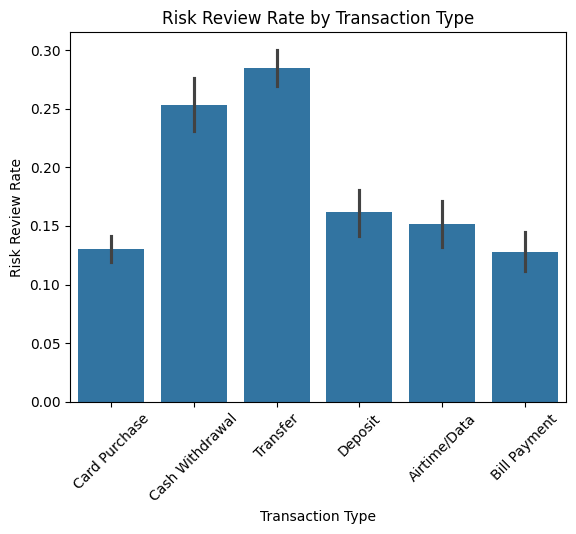

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Transaction_Type', y='Risk_Flag_Numeric', data=df)
plt.title('Risk Review Rate by Transaction Type')
plt.ylabel('Risk Review Rate')
plt.xlabel('Transaction Type')
plt.xticks(rotation=45)
plt.show()

**What it shows:** Risk-review rates vary meaningfully across transaction types. Transfer (28.5%) and Cash Withdrawal (25.3%) are flagged roughly twice as often as Card Purchase (13.0%) and Bill Payment (12.8%), with Deposit (16.2%) and Airtime/Data (15.2%) sitting in between.

**Why it matters:** If risk were spread evenly across transaction types, there'd be little reason to treat any one type differently. The fact that it isn't suggests transaction type itself carries real signal about risk which is directly relevant to a model meant to predict Risk_Review_Flag, and also relevant operationally, since resources for manual review are typically limited.

**Business insight:** FinTrust's risk-review effort could be weighted toward
Transfers and Cash Withdrawals rather than spread evenly across all transaction
types, since that's where flagged activity concentrates. This is a pattern worth investigating further rather than a final explanation on its own.

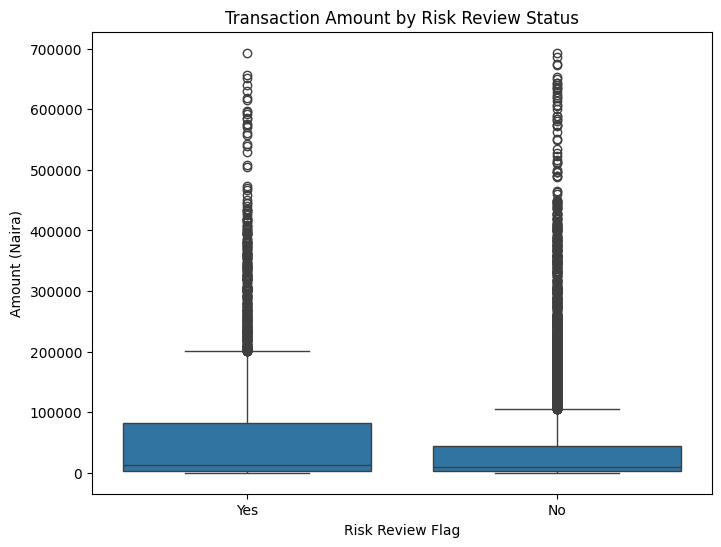

,count,mean,std,min,25%,50%,75%,max
Risk_Review_Flag,,,,,,,,
No,9648.0,41323.976310,77645.567036,100.17,2124.0100,9591.115,43428.94,693006.62
Yes,2352.0,68785.557572,111479.804953,103.14,2520.1525,13541.130,81659.72,693454.45


In [ ]:
# Chart 2 — Amount_NGN (boxplot, numeric vs target)
plt.figure(figsize=(8,6))
sns.boxplot(x='Risk_Review_Flag', y='Amount_NGN', data=df)
plt.title('Transaction Amount by Risk Review Status')
plt.xlabel('Risk Review Flag')
plt.ylabel('Amount (Naira)')
plt.show()

df.groupby('Risk_Review_Flag')['Amount_NGN'].describe()

**What it shows:** Both groups have similar-looking boxes with heavy right-skew and many outliers, but flagged transactions ("Yes") consistently sit higher with a median of NGN 13,541 vs NGN 9,591 for non-flagged, and Q3 NGN 81,660 vs NGN 43,429. The gap between mean (NGN 68,786 vs NGN 41,324) and median is far larger than the gap between medians alone, meaning a small number of very large flagged transactions are pulling the average upward more than the "typical" flagged transaction actually differs from a typical non-flagged one.

**Why it matters:** This tells you Amount_NGN does carry some real signal. Flagged transactions do skew larger but the relationship isn't as dramatic as the mean comparison alone would suggest, and the heavy skew/outliers mean a model may need this feature transformed or binned into amount ranges rather than used raw, so a handful of extreme values don't disproportionately drive predictions.

**Business insight:** Larger transactions do warrant somewhat more scrutiny, but amount alone isn't a clean dividing line between risky and non-risky as plenty of large transactions are still "No," and plenty of small ones are still "Yes". It's a contributing factor to combine with others (like transaction type), not a standalone rule.

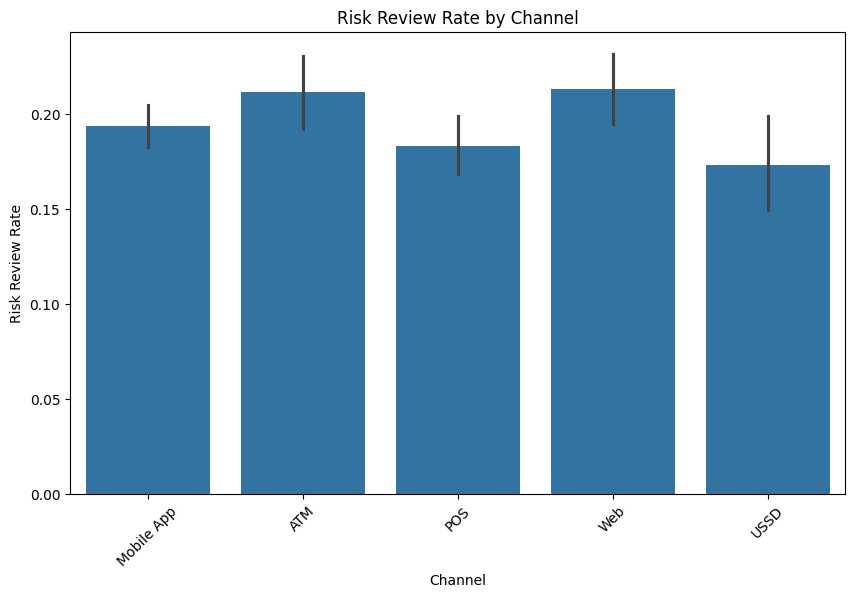

In [ ]:
# Chart 3 — Channel (barplot)
plt.figure(figsize=(10,6))
sns.barplot(x='Channel', y='Risk_Flag_Numeric', data=df)
plt.title('Risk Review Rate by Channel')
plt.xlabel('Channel')
plt.ylabel('Risk Review Rate')
plt.xticks(rotation=45)
plt.show()

**What it shows:** Risk-review rates by channel range narrowly from 17.3% (USSD) to 21.3% (Web), with ATM close behind Web at 21.2%.

**Why it matters:** Unlike Transaction_Type, where the spread between highest and lowest was roughly 16 percentage points, Channel shows only about a 4-point spread suggesting channel alone is a comparatively weak predictor of risk-review status on its own.

**Business insight:** Channel-based monitoring is unlikely to be as useful a risk-prioritization lever as transaction type. This variable may still add some value in combination with other features, but shouldn't be treated as a strong standalone risk indicator.

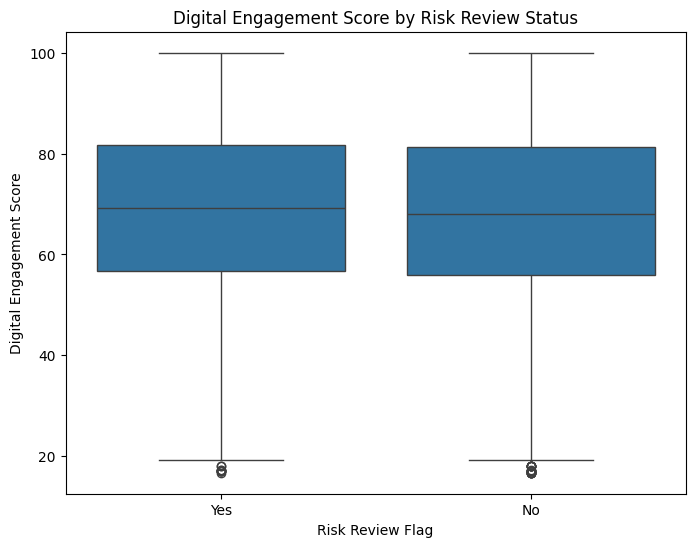

In [ ]:
# Chart 4 — Digital_Engagement_Score (boxplot)
plt.figure(figsize=(8,6))
sns.boxplot(x='Risk_Review_Flag', y='Digital_Engagement_Score', data=df)
plt.title('Digital Engagement Score by Risk Review Status')
plt.xlabel('Risk Review Flag')
plt.ylabel('Digital Engagement Score')
plt.show()

**What it shows:** Digital Engagement Score distributions are nearly identical between the two groups, with almost the same interquartile range in both cases.

**Why it matters:** A variable with no visible separation between the "Yes" and "No" groups is unlikely to help a model distinguish between them.

**Business insight:** Digital engagement alone doesn't appear to be a useful standalone risk indicator. It may still contribute in combination with transaction-level features, but shouldn't be expected to carry meaningful predictive weight on its own, reinforcing a pattern where transaction-level behavior (type, amount) seems more informative than customer-level attributes.

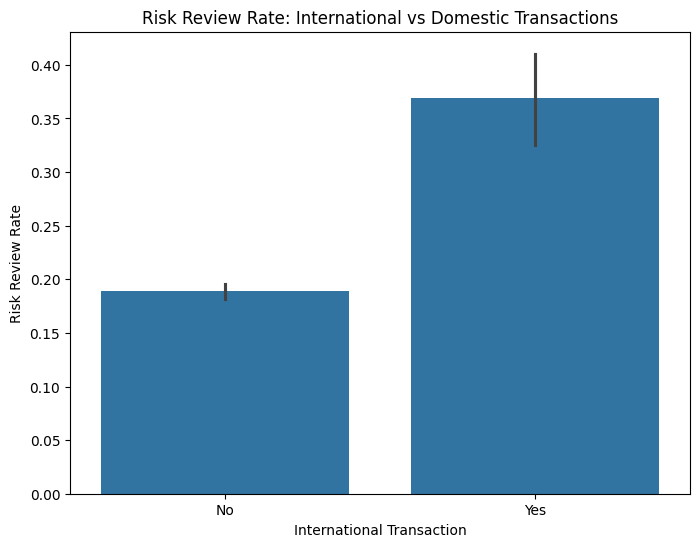

In [ ]:
# Chart 5 — International_Transaction (barplot)
plt.figure(figsize=(8,6))
sns.barplot(x='International_Transaction', y='Risk_Flag_Numeric', data=df)
plt.title('Risk Review Rate: International vs Domestic Transactions')
plt.xlabel('International Transaction')
plt.ylabel('Risk Review Rate')
plt.show()

**What it shows:** International transactions have a risk-review rate of ~37%, compared to ~17% for domestic transactions which is roughly double.

**Why it matters:** International transactions likely carry more inherent uncertainty like currency conversion, less direct oversight, and greater difficulty verifying the counterparty, which possibly explains why they get flagged roughly twice as often.

**Business insight:** A 2x gap is meaningful but not a clean dividing line since a ~37% flag rate means roughly 63% of international transactions are still not flagged. So auto-flagging every international transaction for review would generate a lot of unnecessary manual work (low precision). It's a useful input feature for a model to weigh alongside others, rather than a standalone rule on its own.

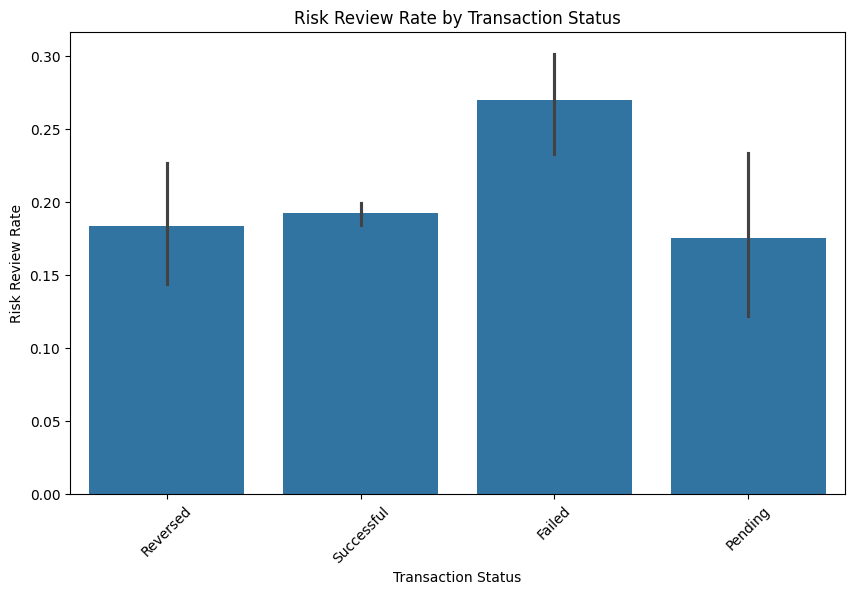

In [ ]:
# Chart 6 — Transaction_Status (barplot)
plt.figure(figsize=(10,6))
sns.barplot(x='Transaction_Status', y='Risk_Flag_Numeric', data=df)
plt.title('Risk Review Rate by Transaction Status')
plt.xlabel('Transaction Status')
plt.ylabel('Risk Review Rate')
plt.xticks(rotation=45)
plt.show()

**What it shows:** Failed transactions carry the highest risk-review rate at 27.0%, notably above Successful (19.2%), Reversed (18.4%), and Pending (17.6%) — though Failed represents a small slice of the data (630 of 12,000 transactions, ~5%), so this pattern rests on a smaller sample than the others.

**Why it matters:** A failed transaction being flagged more often is plausible for concrete reasons — repeated failed attempts can indicate someone testing stolen card details or account credentials, which is a recognizable fraud-adjacent pattern in real banking systems. Given the small sample size, this pattern should be treated as a signal worth investigating further rather than a settled conclusion.

**Business insight:** Transaction status could be a useful input feature, but Failed's elevated rate should be validated against more data over time before FinTrust treats it as a reliable standalone indicator. With only 630 cases, a handful of unusual records could be driving the gap.

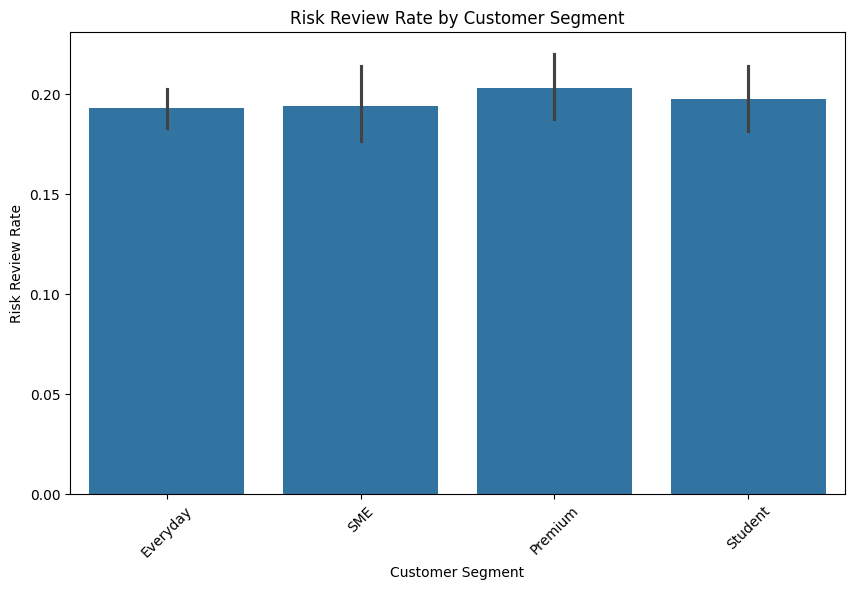

In [ ]:
# Chart 7 — Customer_Segment (barplot)
plt.figure(figsize=(10,6))
sns.barplot(x='Customer_Segment', y='Risk_Flag_Numeric', data=df)
plt.title('Risk Review Rate by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Risk Review Rate')
plt.xticks(rotation=45)
plt.show()

**What it shows:** Risk-review rates are nearly flat across customer segments. Premium is marginally highest at 20.3%, but Student (19.7%), SME (19.4%), and Everyday (19.3%) are all within about one percentage point of each other.

**Why it matters:** This mirrors the pattern already seen with Digital_Engagement_Score that customer-level attributes appear to carry little independent signal about risk, reinforcing that transaction-level behavior (type, amount, international status) is doing most of the work in distinguishing flagged from non-flagged transactions, not who the customer is.

**Business insight:** Customer_Segment is unlikely to be a useful standalone predictor and probably shouldn't be prioritized as a modelling feature on its own though it costs little to include alongside stronger transaction-level features, since it's already available.

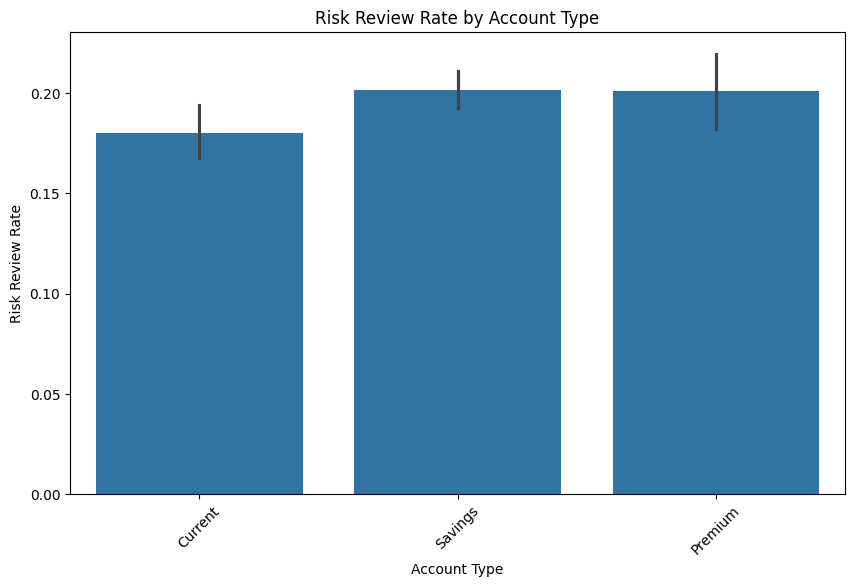

In [ ]:
# Chart 8 — Account_Type (barplot)
plt.figure(figsize=(10,6))
sns.barplot(x='Account_Type', y='Risk_Flag_Numeric', data=df)
plt.title('Risk Review Rate by Account Type')
plt.xlabel('Account Type')
plt.ylabel('Risk Review Rate')
plt.xticks(rotation=45)
plt.show()

**What it shows:** Savings and Premium accounts show nearly identical risk-review rates of (20.1% each)  with Current accounts slightly lower at (18.0%)  a small, roughly 2-point spread.

**Why it matters:** Consistent with Customer_Segment and Digital_Engagement_Score, this reinforces a broader pattern across this EDA: customer/account-level attributes show minimal separation on the risk flag, while transaction-level features (type, international status, amount) show far larger, more meaningful gaps.

**Business insight:** Account_Type isn't a useful standalone predictor. Combined with the other flat customer-level findings, this suggests a modelling strategy that leans on transaction-level features as the primary drivers, with customer-level attributes playing at most a minor supporting role.

##Part C: Feature Engineering

In [8]:
# 1. Transaction Hour
df['Transaction_Hour'] = df['Transaction_DateTime'].dt.hour
# Risk-review rate (% flagged "Yes") by hour, sorted highest to lowest
print('Risk review rate by hour- descending order:')
print(df.groupby('Transaction_Hour')['Risk_Review_Flag'].apply(lambda x: (x=='Yes').mean()).sort_values(ascending=False))

# 2. Transaction Day of Week
df['Transaction_DayOfWeek'] = df['Transaction_DateTime'].dt.day_name()
# Risk-review rate (% flagged "Yes") by day of week, sorted highest to lowest
print() #spacing
print('Risk review rate by day of week- descending order:')
print(df.groupby('Transaction_DayOfWeek')['Risk_Review_Flag'].apply(lambda x: (x=='Yes').mean()).sort_values(ascending=False))

# 3. Amount Band
df['Amount_Band'] = pd.cut(df['Amount_NGN'], bins=[0, 5000, 20000, 50000, 100000, float('inf')],
                             labels=['0-5k', '5k-20k', '20k-50k', '50k-100k', '100k+'])

# 4. High-Risk Transaction Type Flag (based on your EDA: Transfer & Cash Withdrawal stood out)
df['High_Risk_Type'] = df['Transaction_Type'].isin(['Transfer', 'Cash Withdrawal']).astype(int)

# 5. Customer Transaction Count (how many transactions this customer has, total)
df['Customer_Txn_Count'] = df.groupby('Customer_ID')['Transaction_ID'].transform('count')

# 6. Customer Average Transaction Amount
df['Customer_Avg_Amount'] = df.groupby('Customer_ID')['Amount_NGN'].transform('mean')

# 7. Tenure Band
df['Tenure_Band'] = pd.cut(df['Tenure_Months'], bins=[0, 12, 36, 60, float('inf')],
                             labels=['<1yr', '1-3yr', '3-5yr', '5yr+'])

# 8. International Indicator (numeric)
df['Is_International'] = (df['International_Transaction'] == 'Yes').astype(int)

Risk review rate by hour- descending order:
Transaction_Hour
1     0.310
5     0.300
2     0.292
0     0.284
4     0.262
3     0.254
16    0.202
19    0.192
8     0.184
18    0.182
14    0.178
7     0.168
20    0.168
13    0.166
11    0.164
17    0.162
10    0.160
12    0.160
15    0.154
9     0.154
22    0.154
21    0.154
23    0.152
6     0.148
Name: Risk_Review_Flag, dtype: float64

Risk review rate by day of week- descending order:
Transaction_DayOfWeek
Tuesday      0.210040
Sunday       0.201269
Thursday     0.199077
Saturday     0.197232
Wednesday    0.190387
Friday       0.189376
Monday       0.184180
Name: Risk_Review_Flag, dtype: float64


The following features were engineered based on patterns identified during EDA, with several validated directly against the data before inclusion.

| Feature | How It Was Created | Why It May Matter |
|---|---|---|
| `Transaction_Hour` | Extracted hour (0–23) from `Transaction_DateTime` using `.dt.hour` | Overnight hours (12am–5am) show flag rates of 26–31%, well above the 19.6% overall average, plausibly because overnight activity is harder to verify and less typical of legitimate use |
| `Transaction_DayOfWeek` | Extracted day name from `Transaction_DateTime` using `.dt.day_name()` | Tested, but rates are flat (18–21% across all seven days). Like `Customer_Segment`, this does not appear to be a meaningful standalone signal |
| `Amount_Band` | Binned `Amount_NGN` into 5 ranges (0–5k, 5k–20k, 20k–50k, 50k–100k, 100k+) using `pd.cut()` | Supported by EDA (Chart 2), flagged transactions have a notably higher median and Q3 amount, so binning may capture this relationship more cleanly than the raw skewed value |
| `High_Risk_Type` | Flag (1/0) for whether `Transaction_Type` is Transfer or Cash Withdrawal | Directly evidenced by Chart 1, these two types showed the highest risk-review rates (28.5%, 25.3%) of all transaction types |
| `Customer_Txn_Count` | Count of total transactions per `Customer_ID` using `groupby().transform('count')` | Tested the hypothesis that frequent transacting signals risk (e.g. testing card details) but average count is nearly identical between flagged and non-flagged (9.13 vs 9.00), so this feature shows no clear relationship in this data |
| `Customer_Avg_Amount` | Average `Amount_NGN` per `Customer_ID` using `groupby().transform('mean')` | Untested hypothesis that captures a customer's typical spending level, so a transaction can be judged as unusual relative to that customer rather than only in absolute terms; a large transaction may be normal for one customer and highly unusual for another |
| `Tenure_Band` | Binned `Tenure_Months` into 4 ranges (<1yr, 1–3yr, 3–5yr, 5yr+) using `pd.cut()` | Untested hypothesis — newer customers may be less familiar with the platform or less established with the bank, plausibly correlating with different risk patterns; to be tested during modelling |
| `Is_International` | Converted `International_Transaction` Yes/No to 1/0 | Directly evidenced by Chart 5 international transactions are flagged at 37% vs 17% domestic, roughly double |

##Part D: Baseline Model Development
###Part D.1: Prepare modeling data

In [9]:
#drops columns not suitable for modelling
model_df = df.drop(columns=[
    'Transaction_ID',
    'Customer_ID',
    'Customer_Name',
    'Transaction_DateTime',
    'International_Transaction',
    'Amount_NGN',
    'Tenure_Months',
    'High_Risk_Type',
    'Risk_Review_Flag'])

In [11]:
model_df.shape

(12000, 22)

**Data Preparation Decisions**

Column selection: Transaction_ID, Customer_ID, and Customer_Name were excluded as identifier columns with no predictive value and a risk of causing data leakage/overfitting if included.

Transaction_DateTime was excluded in favor of its engineered derivatives (Transaction_Hour, Transaction_DayOfWeek). International_Transaction, Amount_NGN, and Tenure_Months were excluded in favor of their corresponding engineered versions (Is_International, Amount_Band, Tenure_Band respectively) to avoid duplicating the same information twice, and because binned versions may better suit a logistic regression baseline model given potential threshold effects and the skew in Amount_NGN.

High_Risk_Type was excluded since it's a simplification of Transaction_Type, which will be retained in fuller (dummy-encoded) form.

In [12]:
#drops null values
model_df = model_df.dropna()

In [13]:
#checks if it worked
model_df.shape

(11812, 22)

**Decision:** Rows with missing Device_Type or Location values were dropped rather than imputed with a placeholder category.

**Why:** These missing values affect 188 rows out of 12,000 (1.97% of the dataset) - a small enough proportion that dropping them is unlikely to meaningfully bias the dataset or reduce the target's class balance in any noticeable way. Filling with a placeholder like "Unknown" was considered, but since the Data Dictionary confirms this missingness was intentionally introduced for data-quality practice rather than reflecting a genuine real-world pattern, there's no strong reason to preserve these rows as a separate "Unknown" category the model might try to learn from as doing so risks the model treating an artificial data-quality choice as if it were a meaningful signal.

**Trade-off acknowledged:** In a real-world setting with a larger proportion of missing data, dropping rows would be riskier (losing genuine information); here, given the small percentage and known artificial cause, it's a reasonable simplification for a baseline model.

In [ ]:
"""
model_df = pd.get_dummies(model_df)
Automatically detects and encodes every column with an object or category dtype, leaving numeric columns untouched.
"""

In [14]:
#lists the columns out for clarity
model_df = pd.get_dummies(model_df, columns=[
    'Transaction_Type',
    'Channel',
    'Customer_Segment',
    'Account_Type',
    'Transaction_DayOfWeek',
    'Amount_Band',
    'Tenure_Band',
    'Device_Type',
    'Location',
    'Transaction_Status',
    'Monthly_Income_Band',
    'Gender',
    'City',
    'Preferred_Channel',
    'Account_Status'], drop_first=True)

**Categorical Encoding:** All remaining categorical columns (Transaction_Type, Channel, Customer_Segment, Account_Type, Transaction_DayOfWeek, Amount_Band, Tenure_Band, Device_Type, Location, Transaction_Status, Monthly_Income_Band, Gender, City, Preferred_Channel, Account_Status) were converted to numeric form using one-hot encoding (pd.get_dummies()), since scikit-learn models require fully numeric input.

In [15]:
model_df.shape

(11812, 65)

In [16]:
#confirms everything is now numeric
model_df.dtypes.value_counts()

,count
bool,58
int64,4
float64,2
int32,1


###Part D.2: Split the data

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X = model_df.drop(['Risk_Flag_Numeric'], axis=1)
y = model_df['Risk_Flag_Numeric']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,stratify = y)

**Why stratified?** The target is imbalanced (80/20 split), so stratifying ensures both train and test sets preserve that same class ratio rather than risking a skewed split by chance.

###Part D.3: Train the Model

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

LogisticRegression()

**Why Logistic Regression as baseline?** It's simple, interpretable, and gives a reference point before trying more complex algorithms, consistent with the Week 1 modelling plan.

###Part D.4: Generate Predictions

In [29]:
y_pred = lr.predict(X_test_scaled)

###Part D.5: Initial Evaluation

In [30]:
from sklearn import metrics
accuracy = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", {accuracy})

Accuracy: {0.8027930596699111}


Baseline model achieved 0.80 accuracy. However, given the 80/20 class imbalance in Risk_Review_Flag, this number alone is not meaningful. A model that predicted "No" for every transaction would score similarly high without learning anything. A full evaluation with precision, recall, and F1-score is required to properly assess performance (see Part E)

##Part E: Model Evaluation

In [31]:
class_report = metrics.classification_report(y_test, y_pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.81      0.99      0.89      1898
           1       0.47      0.02      0.04       465

    accuracy                           0.80      2363
   macro avg       0.64      0.51      0.46      2363
weighted avg       0.74      0.80      0.72      2363



**Model Evaluation:** The baseline Logistic Regression achieved 0.80 overall accuracy, but this figure is misleading given the 80/20 class imbalance. Per-class metrics reveal the real picture: for the "Yes" (risk-review) class, precision was 0.47, recall was just 0.02, and F1 was 0.04. Recall measures how many of the actual risky transactions the model successfully caught. A recall of 0.02 means the model caught only about 2% of the real risky transactions in the test set. It labeled the vast majority of them as 'safe' when they were actually risky, missing nearly all of the cases it was supposed to detect.

This confirms the reasoning established in Week 1: accuracy alone is not an appropriate metric here, since missing a risky transaction (false negative) is the costlier error for FinTrust, and recall/F1 must be weighted far more heavily than raw accuracy when judging this model's usefulness.

##Part F: Model Interpretation

In [34]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)
print('Feature importance:')
print(importance)

Feature importance:
                             Feature  Coefficient
10         Transaction_Type_Transfer     0.285688
2                   Transaction_Hour    -0.254037
5                   Is_International     0.203341
29                 Amount_Band_100k+     0.194273
8   Transaction_Type_Cash Withdrawal     0.178749
..                               ...          ...
51                       Gender_Male    -0.004853
63         Account_Status_Restricted     0.004066
54                        City_Enugu    -0.001375
48     Monthly_Income_Band_250k-499k     0.000736
23    Transaction_DayOfWeek_Thursday     0.000405

[64 rows x 2 columns]


### Feature Importance (Top 5, by absolute coefficient)

| Feature | Coefficient | Evidence | Interpretation |
|---|---|---|---|
| `Transaction_Type_Transfer` | +0.286 | Chart 1 (EDA) showed Transfer had the highest risk-review rate (28.5%) of all transaction types | The strongest driver in the model — being a Transfer pushes the prediction toward "risky" more than any other single feature, consistent with the EDA finding |
| `Transaction_Hour` | -0.254 | Overnight hours (0–5) show elevated risk (25–31%), while hours 6–23 are uniformly lower (15–20%) | The negative sign captures the general direction (early hours riskier) but is a linear approximation of what is actually a step/threshold pattern, not a smooth decline across all 24 hours. A binned "Overnight vs. Daytime" feature may represent this relationship more accurately in a future iteration |
| `Is_International` | +0.203 | Chart 5 (EDA) showed international transactions flagged at 37% vs 17% domestic | Confirms international status as a meaningful, independent risk driver even after accounting for other features |
| `Amount_Band_100k+` | +0.194 | Chart 2 (EDA) showed flagged transactions had a notably higher median and Q3 amount | The highest amount band contributes a meaningful push toward "risky," consistent with the amount-based pattern found in EDA |
| `Transaction_Type_Cash Withdrawal` | +0.179 | Chart 1 (EDA) showed Cash Withdrawal had the second-highest risk-review rate (25.3%) | Reinforces that specific transaction types, not just amount or international status, independently matter to the model's predictions |

**Overall interpretation:** The model's most influential features are consistent with what EDA already suggested- transaction type, international status, transaction amount, and time of day carry real signal, while (consistent with EDA) customer-level attributes like segment, account type, and engagement score did not appear among the top drivers.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X = model_df.drop(columns='Risk_Flag_Numeric')
y = model_df['Risk_Flag_Numeric']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_balanced = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = lr_balanced.predict(X_test_scaled)

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

print("Baseline Model (default):")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

print("\n Balanced Model (class_weight='balanced'):")
print(classification_report(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))

Baseline Model (default):
              precision    recall  f1-score   support

           0       0.80      0.99      0.89      1898
           1       0.21      0.01      0.02       465

    accuracy                           0.80      2363
   macro avg       0.51      0.50      0.45      2363
weighted avg       0.69      0.80      0.72      2363

[[1883   15]
 [ 461    4]]

 Balanced Model (class_weight='balanced'):
              precision    recall  f1-score   support

           0       0.86      0.62      0.72      1898
           1       0.28      0.60      0.38       465

    accuracy                           0.61      2363
   macro avg       0.57      0.61      0.55      2363
weighted avg       0.75      0.61      0.65      2363

[[1173  725]
 [ 187  278]]


**Addressing the Recall Problem: `class_weight='balanced'`**

The baseline model (Part E) achieved 0.80 accuracy but only 0.01 recall, it caught almost none of the genuinely risky transactions. To address this, the model was retrained with `class_weight='balanced'`, which weights the minority ("Yes") class more heavily during training:

| Metric | Baseline (default) | `class_weight='balanced'` |
|---|---|---|
| Accuracy | 0.80 | 0.61 |
| Precision (class 1) | 0.21 | 0.28 |
| Recall (class 1) | 0.01 | 0.60 |
| F1 (class 1) | 0.02 | 0.38 |

**Interpretation:** Applying `class_weight='balanced'` substantially improved recall (0.01 to 0.60), meaning the model now catches roughly 60% of genuinely risky transactions instead of 1%. The confusion matrix confirms this directly: the baseline model correctly caught only 4 of 465 risky transactions, while the balanced model caught 278 of 465. This came at a real cost as accuracy dropped from 0.80 to 0.61, and precision remains low (0.28), meaning many "No" transactions are now incorrectly flagged (725 false positives). Given the project's own reasoning, that missing a risky transaction is the costlier error for FinTrust, this trade-off is justified: a model that catches most real risk at the cost of a higher manual-review workload is more useful than one that looks accurate but misses almost everything it's meant to detect.

###Limitations

**Synthetic target:** Risk_Review_Flag is a synthetic, educational label and does not represent a real fraud or risk determination. Model results demonstrate a modelling approach, not a validated real-world risk-detection capability.

**Class imbalance:** Even after class_weight='balanced', precision remains low (0.27). The model still generates a meaningful number of false positives, which would translate to unnecessary manual review workload in practice.

**Linear model limitations:** Logistic Regression assumes linear relationships between raw numeric features and the outcome, which does not fully capture threshold/step effects observed in Transaction_Hour and likely Amount_NGN. A tree-based model (e.g. Random Forest) may capture these non-linear patterns more effectively.

**Untested features:** Customer_Avg_Amount and Tenure_Band were included as plausible hypotheses but not independently validated against the target before modelling; their contribution should be interpreted with that caution.

**Small-sample categories:** Categories such as "Failed" transaction status (630 records) and "Prefer not to say" gender (51 records) are based on limited data and may produce less stable coefficient estimates.

**Areas for further investigation:** Testing tree-based models, tuning the classification threshold instead of only reweighting classes, and validating Customer_Avg_Amount/Tenure_Band against the target directly.